In [4]:
import pandas as pd # 파이썬 프로그래밍 언어 > 행.열 기반으로 되어있는 테이블 형태로 자료구조 생성하도록 지원하는 모듈

FILE_PATH = "연관키워드 20260921 1347.xlsx"

df = pd.read_excel(FILE_PATH, header=1)

df.head()

,Unnamed: 0,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),Unnamed: 7,Unnamed: 8
0,도서,"7,780","13,500",84.0,239.2,1.11%,1.88%,높음,10
1,독서,"1,070","3,840",0.5,10.4,0.05%,0.29%,높음,10
2,YES24,"168,900","303,300",111.0,"1,412",0.08%,0.5%,낮음,1
3,베스트셀러,"13,000","36,600",118.6,"1,031.9",0.93%,3.02%,높음,10
4,인터넷서점,"1,620","3,010",78.3,218.8,4.99%,7.67%,높음,10


In [5]:
df.columns = [
    "keyword",
    "search_pc",
    "search_mobile",
    "click_pc",
    "click_mobile",
    "ctr_pc",
    "ctr_mobile",
    "competition",
    "ad_count"
]

df.head() # default 5

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count
0,도서,"7,780","13,500",84.0,239.2,1.11%,1.88%,높음,10
1,독서,"1,070","3,840",0.5,10.4,0.05%,0.29%,높음,10
2,YES24,"168,900","303,300",111.0,"1,412",0.08%,0.5%,낮음,1
3,베스트셀러,"13,000","36,600",118.6,"1,031.9",0.93%,3.02%,높음,10
4,인터넷서점,"1,620","3,010",78.3,218.8,4.99%,7.67%,높음,10


In [ ]:
# 파이썬 프로그래밍 언어 > 팬다스 모듈 > 해당 데이터가 어떤 형태, 사이즈의 데이터인지를 우선 확인하는 과정
# 탐색적 데이터 분석 과정 = EDA = Exploratory Data Analysis
# 데이터 사이즈 (행.열), 데이터가 누락된건 없는지, 타입 숫자, 문자 조회!!!

In [6]:
df.shape # 몇 행.열 -> 분석할만한 가치 > 사이즈

(1000, 9)

In [7]:
df.info() # 9개의 열이 각각 어떤 데이터 타입 수집 = 스키마 확인, 각 열마다 결측치 = Null 값 조회
# object = 문자열 | 혼합데이터 (문자 + 정수, 정수 + 논리)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   keyword        1000 non-null   str    
 1   search_pc      1000 non-null   str    
 2   search_mobile  1000 non-null   str    
 3   click_pc       1000 non-null   float64
 4   click_mobile   1000 non-null   object 
 5   ctr_pc         1000 non-null   str    
 6   ctr_mobile     1000 non-null   str    
 7   competition    1000 non-null   str    
 8   ad_count       1000 non-null   int64  
dtypes: float64(1), int64(1), object(1), str(6)
memory usage: 105.3+ KB


In [8]:
df.head(10)

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count
0,도서,"7,780","13,500",84.0,239.2,1.11%,1.88%,높음,10
1,독서,"1,070","3,840",0.5,10.4,0.05%,0.29%,높음,10
2,YES24,"168,900","303,300",111.0,"1,412",0.08%,0.5%,낮음,1
3,베스트셀러,"13,000","36,600",118.6,"1,031.9",0.93%,3.02%,높음,10
4,인터넷서점,"1,620","3,010",78.3,218.8,4.99%,7.67%,높음,10
5,책베스트셀러,"3,010","13,100",30.2,314.7,1.03%,2.56%,높음,10
6,온라인서점,650,"1,490",26.7,83.4,4.19%,5.86%,높음,10
7,신간도서,600,"1,870",6.1,41.9,1.04%,2.39%,높음,10
8,책쓰기,110,130,0.6,0.5,0.57%,0.38%,높음,10
9,책추천,"3,360","15,200",2.3,35.5,0.07%,0.25%,높음,10


In [21]:
df.tail() # 수집된 데이터 중 아래에서부터 5개

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count
995,난책읽기가좋아2단계,20,120,0.1,2,0.68%,1.74%,중간,7
996,너도하늘말나리야,160,680,0.0,0,-,-,높음,3
997,국어문제,60,250,0.4,2,0.69%,0.84%,높음,10
998,무료한글공부,30,10,0.3,0,0.8%,-,높음,7
999,한글교재,170,380,0.4,4.2,0.23%,1.17%,높음,10


In [10]:
# 현재 데이터 안에서 열 제목만 추출
df.columns

Index(['keyword', 'search_pc', 'search_mobile', 'click_pc', 'click_mobile',
       'ctr_pc', 'ctr_mobile', 'competiton', 'ad_count'],
      dtype='object')

In [11]:
# 각 열 = 컬럼 속성값 확인 = 스키마
df.dtypes

keyword           object
search_pc         object
search_mobile     object
click_pc         float64
click_mobile      object
ctr_pc            object
ctr_mobile        object
competiton        object
ad_count           int64
dtype: object

In [14]:
df[df["keyword"].isna()] # False => 결측치가 아니다, True => 결측치!

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count


In [18]:
# 중복된 값이 있다면, 해당 중복된 값의 갯수

df["keyword"].duplicated().sum()

np.int64(0)

In [26]:
# 중복된 값이 있다면, 해당 요소를 찾아와라

df[df["keyword"].duplicated(keep=False)] # first

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count


In [49]:
# 상관관계 따져보려고 합니다.
# 1857~1936 : 현대 수리통계학의 아버지 : 칼 피어슨 (영국)
# 상관계수 => 서로 다른 두개의 변수가 얼만큼 상관관계를 갖고 있는가를 -1 0 1 측정
# 상관계수 => 상관관계가 있다 없다 판단
# 9개의 컬럼으로 구성되어있는 데이터 => 서로 각 열들끼리 상관관계 있을까?
# 상관관계 있을 수록 0에서 멀어짐 

number_cols = ["search_pc", "search_mobile", "click_pc", "click_mobile", "ad_count"]

for col in number_cols : 
    df[col] = df[col].astype(str).str.replace(",", "", regex=False) # 17, 123 => 17123 완벽한 숫자로 바꾸기(쉼표 없애기) / 정식 정규표현식은 아님 regex=False생략 가능
    df[col] = pd.to_numeric(df[col], errors="coerce") #NaN


In [8]:
ctr_cols = ["ctr_pc", "ctr_mobile"]

for col in ctr_cols :
    df[col] = df[col].astype(str).str.replace("%", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
df

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count
0,도서,"7,780","13,500",84.0,239.2,1.11,1.88,높음,10
1,독서,"1,070","3,840",0.5,10.4,0.05,0.29,높음,10
2,YES24,"168,900","303,300",111.0,"1,412",0.08,0.50,낮음,1
3,베스트셀러,"13,000","36,600",118.6,"1,031.9",0.93,3.02,높음,10
4,인터넷서점,"1,620","3,010",78.3,218.8,4.99,7.67,높음,10
...,...,...,...,...,...,...,...,...,...
995,난책읽기가좋아2단계,20,120,0.1,2,0.68,1.74,중간,7
996,너도하늘말나리야,160,680,0.0,0,NaN,NaN,높음,3
997,국어문제,60,250,0.4,2,0.69,0.84,높음,10
998,무료한글공부,30,10,0.3,0,0.80,NaN,높음,7


In [51]:
df["search_total"] = df["search_pc"] + df["search_mobile"]

df

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0
...,...,...,...,...,...,...,...,...,...,...
995,난책읽기가좋아2단계,20.0,120.0,0.1,2.0,0.68,1.74,중간,7,140.0
996,너도하늘말나리야,160.0,680.0,0.0,0.0,NaN,NaN,높음,3,840.0
997,국어문제,60.0,250.0,0.4,2.0,0.69,0.84,높음,10,310.0
998,무료한글공부,30.0,10.0,0.3,0.0,0.80,NaN,높음,7,40.0


In [28]:
df["click_total"] = df["click_pc"] + df["click_mobile"]

df["mobile_ratio"] = df["search_mobile"]/df["search_total"] * 100 # 모바일 비율이 압도적으로 높기 때문에 백분율로 보기

TypeError: unsupported operand type(s) for +: 'float' and 'str'

In [53]:
df

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799
...,...,...,...,...,...,...,...,...,...,...,...,...
995,난책읽기가좋아2단계,20.0,120.0,0.1,2.0,0.68,1.74,중간,7,140.0,2.1,85.714286
996,너도하늘말나리야,160.0,680.0,0.0,0.0,NaN,NaN,높음,3,840.0,0.0,80.952381
997,국어문제,60.0,250.0,0.4,2.0,0.69,0.84,높음,10,310.0,2.4,80.645161
998,무료한글공부,30.0,10.0,0.3,0.0,0.80,NaN,높음,7,40.0,0.3,25.000000


In [29]:
df.head() # 위에서 다섯개만 보기

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count,search_total,click_total,mobile_ratio
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799


In [30]:
df.describe() # 현재의 df을 묘사 (= 최대값, 최소값, 상위 25%, 하위 25%, 평균, 중앙값) 해주는 매서드

,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,ad_count,search_total,click_total,mobile_ratio
count,731.000000,896.000000,1000.000000,1000.000000,580.000000,716.000000,1000.000000,7.270000e+02,1000.000000,727.000000
mean,981.901505,1848.604911,1.592900,14.631400,2.491931,2.735978,6.655000,3.260385e+03,16.224300,75.095076
std,14108.023708,25217.544158,9.511644,142.927384,4.536663,3.098969,3.229614,4.206940e+04,151.404411,12.787567
min,10.000000,10.000000,0.000000,0.000000,0.030000,0.040000,0.000000,2.000000e+01,0.000000,10.526316
25%,20.000000,30.000000,0.000000,0.000000,0.380000,0.577500,3.000000,9.000000e+01,0.300000,68.000000
50%,50.000000,120.000000,0.200000,1.000000,1.120000,1.610000,7.000000,2.600000e+02,1.100000,77.777778
75%,170.000000,460.000000,0.700000,4.000000,2.860000,3.722500,10.000000,8.050000e+02,4.700000,84.063492
max,340700.000000,685200.000000,200.300000,4051.400000,50.000000,25.000000,10.000000,1.025900e+06,4251.700000,97.500000


In [54]:
df[
    [
        "search_pc", 
        "search_mobile", 
        "search_total", 
        "click_pc", 
        "click_mobile", 
        "click_total",
        "ctr_pc",
        "ctr_mobile",
        "mobile_ratio"
    ]
].describe().round(2)

,search_pc,search_mobile,search_total,click_pc,click_mobile,click_total,ctr_pc,ctr_mobile,mobile_ratio
count,731.00,896.00,727.00,1000.00,1000.00,1000.00,580.00,716.00,727.00
mean,981.90,1848.60,3260.39,1.59,14.63,16.22,2.49,2.74,75.10
std,14108.02,25217.54,42069.40,9.51,142.93,151.40,4.54,3.10,12.79
min,10.00,10.00,20.00,0.00,0.00,0.00,0.03,0.04,10.53
25%,20.00,30.00,90.00,0.00,0.00,0.30,0.38,0.58,68.00
50%,50.00,120.00,260.00,0.20,1.00,1.10,1.12,1.61,77.78
75%,170.00,460.00,805.00,0.70,4.00,4.70,2.86,3.72,84.06
max,340700.00,685200.00,1025900.00,200.30,4051.40,4251.70,50.00,25.00,97.50


In [32]:
df # 위 분석은 Five Number Summary로 원래 df는 그대로 유지, 변경이 되지는 않는다. dataframe = 행과 열 기반으로 구성되어있는 자료

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count,search_total,click_total,mobile_ratio
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799
...,...,...,...,...,...,...,...,...,...,...,...,...
995,난책읽기가좋아2단계,20.0,120.0,0.1,2.0,0.68,1.74,중간,7,140.0,2.1,85.714286
996,너도하늘말나리야,160.0,680.0,0.0,0.0,NaN,NaN,높음,3,840.0,0.0,80.952381
997,국어문제,60.0,250.0,0.4,2.0,0.69,0.84,높음,10,310.0,2.4,80.645161
998,무료한글공부,30.0,10.0,0.3,0.0,0.80,NaN,높음,7,40.0,0.3,25.000000


In [55]:
top_search = df.sort_values("search_total", ascending=False).head(20) # ascending 안쓸거야 -> 내림차순

top_search

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
78,예스24,340700.0,685200.0,200.3,4051.4,0.07,0.63,낮음,1,1025900.0,4251.7,66.790135
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
22,도서관,9220.0,80000.0,7.3,40.9,0.09,0.06,높음,3,89220.0,48.2,89.665994
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
467,시나공,28600.0,19100.0,29.0,117.8,0.11,0.66,중간,3,47700.0,146.8,40.041929
94,베스트셀러순위,3790.0,19600.0,33.8,419.0,0.92,2.28,높음,10,23390.0,452.8,83.796494
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
70,공모전,9520.0,11300.0,48.8,124.2,0.54,1.16,높음,10,20820.0,173.0,54.274736
9,책추천,3360.0,15200.0,2.3,35.5,0.07,0.25,높음,10,18560.0,37.8,81.896552
5,책베스트셀러,3010.0,13100.0,30.2,314.7,1.03,2.56,높음,10,16110.0,344.9,81.315953


In [34]:
top_search[["keyword", "search_pc", "search_mobile", "search_total"]]

,keyword,search_pc,search_mobile,search_total
78,예스24,340700.0,685200.0,1025900.0
2,YES24,168900.0,303300.0,472200.0
22,도서관,9220.0,80000.0,89220.0
3,베스트셀러,13000.0,36600.0,49600.0
467,시나공,28600.0,19100.0,47700.0
94,베스트셀러순위,3790.0,19600.0,23390.0
0,도서,7780.0,13500.0,21280.0
70,공모전,9520.0,11300.0,20820.0
9,책추천,3360.0,15200.0,18560.0
5,책베스트셀러,3010.0,13100.0,16110.0


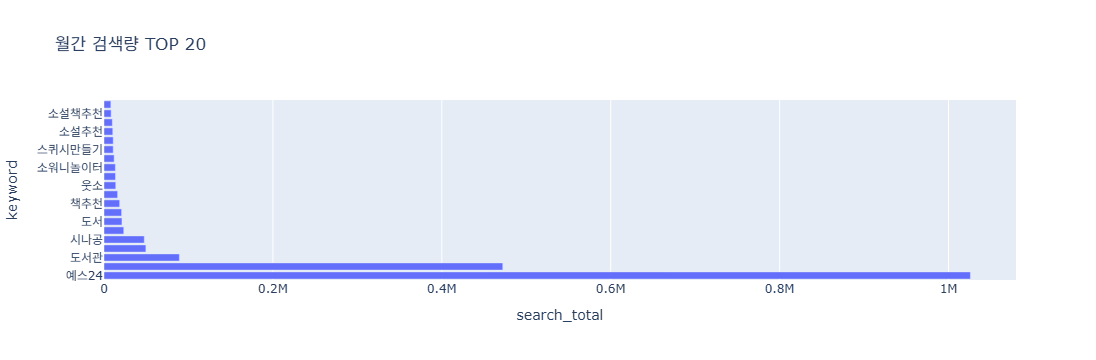

In [56]:
import plotly.express as px # express 빨리

fig = px.bar(
    top_search,
    x="search_total",
    y="keyword",
    orientation="h",
    title="월간 검색량 TOP 20"
)
fig.show()

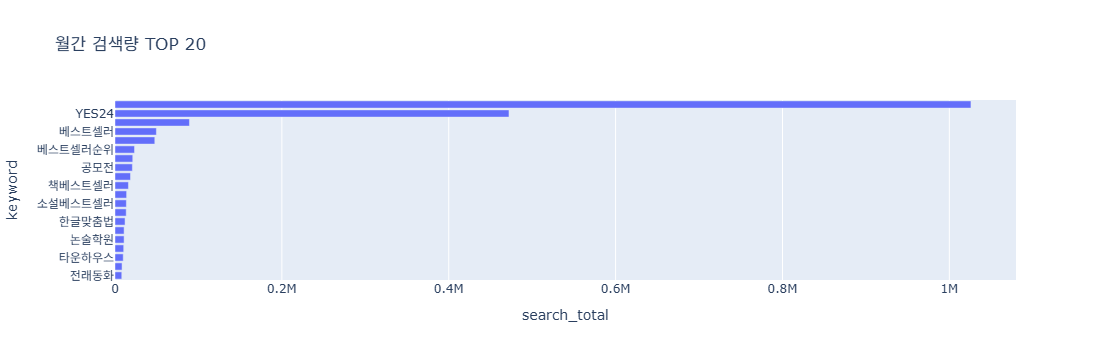

In [57]:
import plotly.express as px # express 빨리

fig = px.bar(
    top_search,
    x="search_total",
    y="keyword",
    orientation="h",
    title="월간 검색량 TOP 20"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

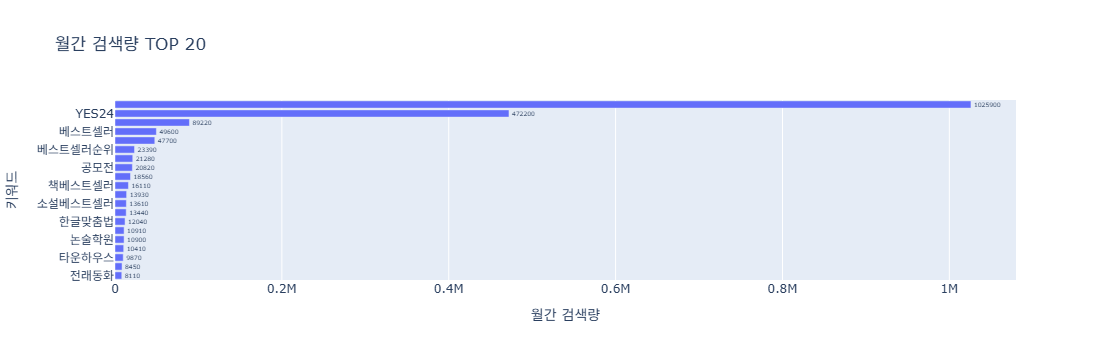

In [58]:
import plotly.express as px # express 빨리

fig = px.bar(
    top_search,
    x="search_total",
    y="keyword",
    orientation="h",
    title="월간 검색량 TOP 20",
    labels={
        "search_total": "월간 검색량",
        "keyword": "키워드"
    },
    text="search_total"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.update_traces(
    textposition="outside"
)

fig.show()

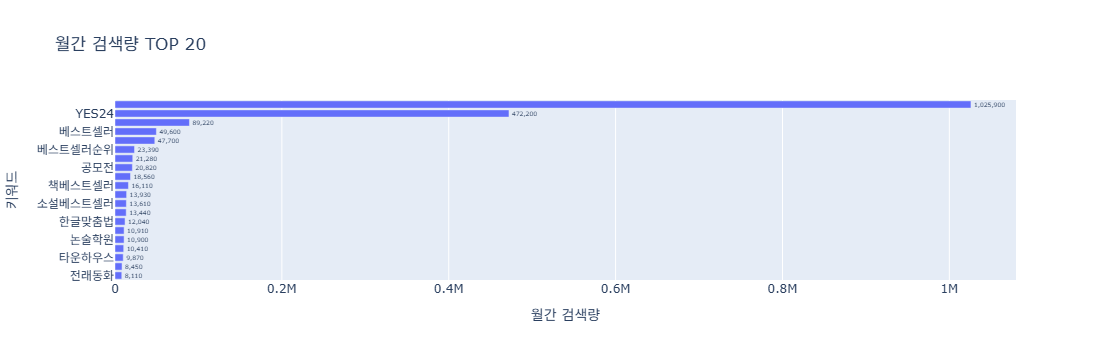

In [59]:
import plotly.express as px # express 빨리

fig = px.bar(
    top_search,
    x="search_total",
    y="keyword",
    orientation="h",
    title="월간 검색량 TOP 20",
    labels={
        "search_total": "월간 검색량",
        "keyword": "키워드"
    },
    text="search_total"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.update_traces(
    texttemplate="%{text:,}", # 1000의 자리에 쉼표
    textposition="outside"
)

fig.show()

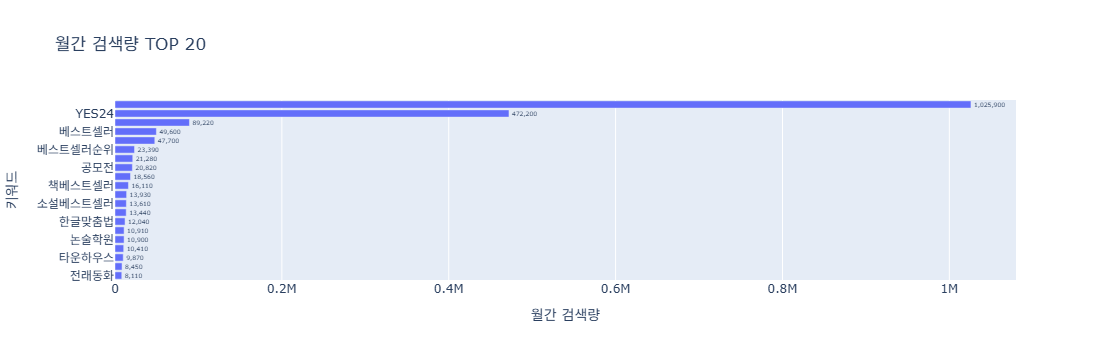

In [60]:
import plotly.express as px # express 빨리

fig = px.bar(
    top_search,
    x="search_total",
    y="keyword",
    orientation="h",
    title="월간 검색량 TOP 20",
    labels={
        "search_total": "월간 검색량",
        "keyword": "키워드"
    },
    text="search_total"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.update_traces(
    texttemplate="%{text:,.0f}", # 1000의 자리에 쉼표, 소수점을 안쓰겠다. 2가 되면 소수점 두번째자리까지    
    textposition="outside"
)

fig.show()

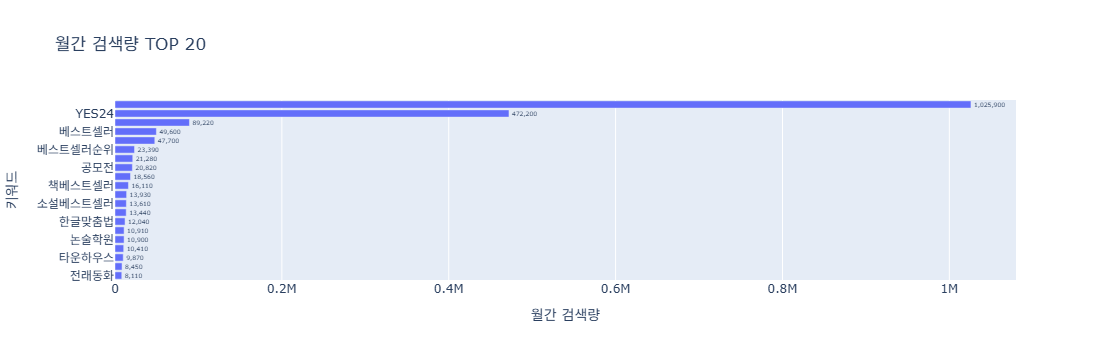

In [61]:
import plotly.express as px # express 빨리

fig = px.bar(
    top_search,
    x="search_total",
    y="keyword",
    orientation="h",
    title="월간 검색량 TOP 20",
    labels={
        "search_total": "월간 검색량",
        "keyword": "키워드",
        "search_pc": "PC 검색량",
        "search_mobile": "Mobile 검색량",
        "competition": "경쟁정도"
    },
    hover_data=[
       "search_pc",
       "search_mobile",
       "competition"
    ],
    text="search_total"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.update_traces(
    texttemplate="%{text:,.0f}", # 1000의 자리에 쉼표, 소수점을 안쓰겠다. 2가 되면 소수점 두번째자리까지    
    textposition="outside"
)

fig.show()

In [62]:
top20 = top_search.copy() # 본인 자기 자신을 복제

In [63]:
top20

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
78,예스24,340700.0,685200.0,200.3,4051.4,0.07,0.63,낮음,1,1025900.0,4251.7,66.790135
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
22,도서관,9220.0,80000.0,7.3,40.9,0.09,0.06,높음,3,89220.0,48.2,89.665994
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
467,시나공,28600.0,19100.0,29.0,117.8,0.11,0.66,중간,3,47700.0,146.8,40.041929
94,베스트셀러순위,3790.0,19600.0,33.8,419.0,0.92,2.28,높음,10,23390.0,452.8,83.796494
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
70,공모전,9520.0,11300.0,48.8,124.2,0.54,1.16,높음,10,20820.0,173.0,54.274736
9,책추천,3360.0,15200.0,2.3,35.5,0.07,0.25,높음,10,18560.0,37.8,81.896552
5,책베스트셀러,3010.0,13100.0,30.2,314.7,1.03,2.56,높음,10,16110.0,344.9,81.315953


In [66]:
top20_device = top20.melt(
    id_vars="keyword", 
    value_vars=[
        "search_pc", "search_mobile"
    ], 
    var_name="device",
    value_name="search_volume"
) 

top20_device.head()

# 왜 이렇게 볼까? : 데이터라는 것은 처음에는 숲을 먼저 봄(큰 덩어리 위조로 조회) / 두번째부터는 숲 안에 있는 세부적 요소를 조회

,keyword,device,search_volume
0,예스24,search_pc,340700.0
1,YES24,search_pc,168900.0
2,도서관,search_pc,9220.0
3,베스트셀러,search_pc,13000.0
4,시나공,search_pc,28600.0


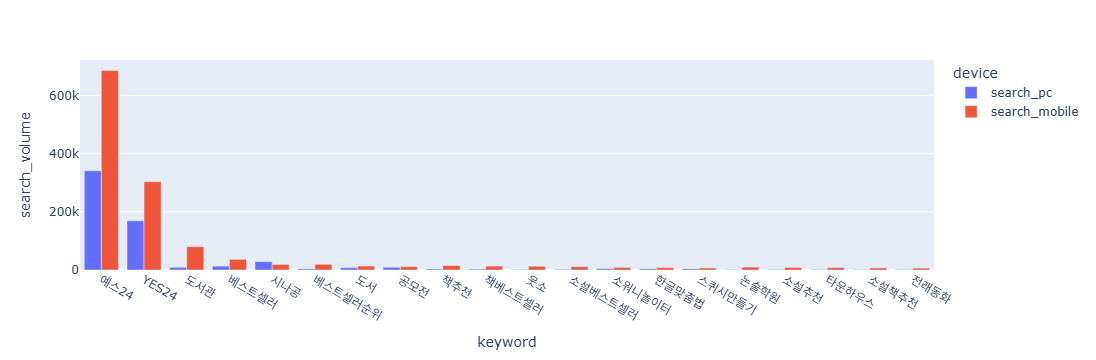

In [72]:
fig = px.bar(
    top20_device,
    x="keyword",
    y="search_volume",
    barmode="group",
    color="device"
)

fig.show()

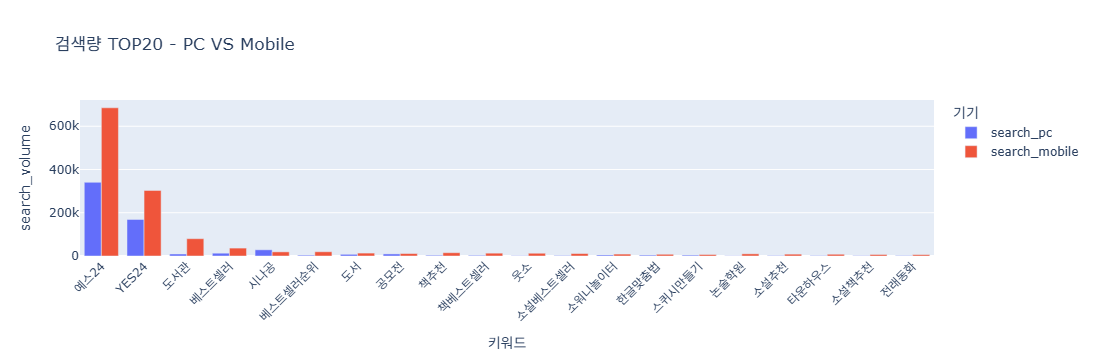

In [74]:
fig = px.bar(
    top20_device,
    x="keyword",
    y="search_volume",
    barmode="group",
    color="device",

    title = "검색량 TOP20 - PC VS Mobile",

    labels = {
        "keyword": "키워드",
        "search_volumn": "월간 검색량",
        "device": "기기"
    }
)
fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [75]:
# 최초 : 전체검색키워드 상위 20
# 두번째 : 상위 20개 키워드의 기기별 검색 빈도 -> 모바일 압승
# 세번째 : 전체 검색 키워드 = 검색량 1000건 이상인 조건 해당되는 요소 찾아오기

df["search_total"] # 전체 검색수

0       21280.0
1        4910.0
2      472200.0
3       49600.0
4        4630.0
         ...   
995       140.0
996       840.0
997       310.0
998        40.0
999       550.0
Name: search_total, Length: 1000, dtype: float64

In [76]:
# 최초 : 전체검색키워드 상위 20
# 두번째 : 상위 20개 키워드의 기기별 검색 빈도 -> 모바일 압승
# 세번째 : 전체 검색 키워드 = 검색량 1000건 이상인 조건 해당되는 요소 찾아오기
# 네번째 : 단순 검색량만 높은게 아니라, 클릭빈도 = 클릭율이 높은 키워드 & 모바일 검색수가 500이상 

df[df["search_total"] >= 1000] # 1000건 이상

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799
...,...,...,...,...,...,...,...,...,...,...,...,...
981,전래동화,1800.0,6310.0,1.5,10.2,0.09,0.18,높음,10,8110.0,11.7,77.805179
982,다독다독과학,130.0,1020.0,0.5,12.7,0.38,1.32,높음,10,1150.0,13.2,88.695652
986,E북무료,210.0,1230.0,2.4,35.6,1.17,3.06,높음,9,1440.0,38.0,85.416667
989,무료전자책,650.0,2490.0,10.8,52.0,1.70,2.20,높음,10,3140.0,62.8,79.299363


In [77]:
mobile_keywords = (
    df[df["search_total"] >= 1000]
    .sort_values(
        "mobile_ratio", ascending=False
    ).head(20)
    .copy()
) # 모바일 기준 상위 20개만 보기 / copy() => pandas의 문법은 어떤 필터링, 조건을 적용했을 때 원본값이 변경되지 않음 // 별도로 생성.저장 관리하는 습관을 들이자. 본인 스스로를 복제해서 데이터 저장해놓기

In [78]:
mobile_keywords

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
381,말이야와친구들,150.0,3400.0,0.0,2.0,NaN,0.07,높음,3,3550.0,2.0,95.774648
938,국어문제집,150.0,1750.0,0.7,2.0,0.48,0.13,높음,10,1900.0,2.7,92.105263
153,논술학원,930.0,9970.0,5.2,62.6,0.57,0.66,높음,10,10900.0,67.8,91.467890
438,웃소,1230.0,12700.0,0.0,0.0,NaN,NaN,중간,3,13930.0,0.0,91.170136
614,독서학원,110.0,1100.0,0.3,6.0,0.26,0.57,높음,10,1210.0,6.3,90.909091
964,읽으면서바로써먹는,230.0,2150.0,1.6,37.8,0.73,1.92,높음,10,2380.0,39.4,90.336134
499,코믹스,240.0,2190.0,6.3,238.4,2.73,11.69,중간,6,2430.0,244.7,90.123457
722,논술준비,130.0,1160.0,0.2,9.7,0.16,0.88,높음,10,1290.0,9.9,89.922481
22,도서관,9220.0,80000.0,7.3,40.9,0.09,0.06,높음,3,89220.0,48.2,89.665994
632,초1추천도서,150.0,1240.0,0.1,0.8,0.10,0.07,높음,7,1390.0,0.9,89.208633


In [79]:
mobile_keywords[
    [
        "keyword",
        "search_total",
        "search_mobile",
        "mobile_ratio"
    ]
].round(2) # mobile_ratio 이것때문에 소수점 두째자리

,keyword,search_total,search_mobile,mobile_ratio
381,말이야와친구들,3550.0,3400.0,95.77
938,국어문제집,1900.0,1750.0,92.11
153,논술학원,10900.0,9970.0,91.47
438,웃소,13930.0,12700.0,91.17
614,독서학원,1210.0,1100.0,90.91
964,읽으면서바로써먹는,2380.0,2150.0,90.34
499,코믹스,2430.0,2190.0,90.12
722,논술준비,1290.0,1160.0,89.92
22,도서관,89220.0,80000.0,89.67
632,초1추천도서,1390.0,1240.0,89.21


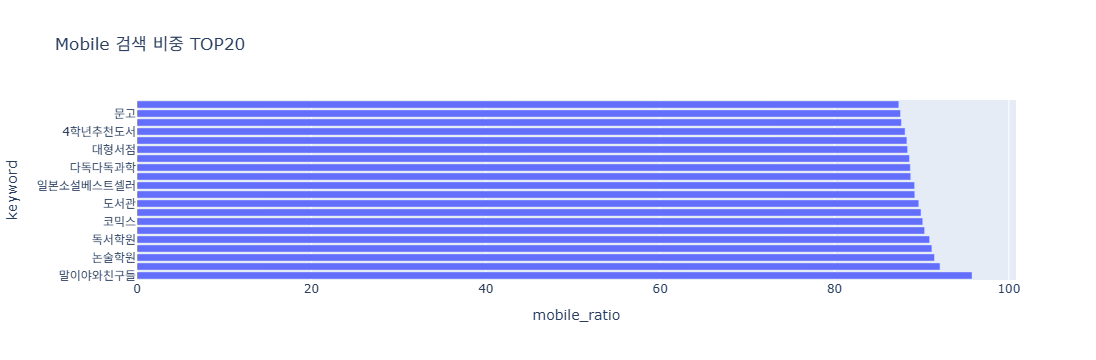

In [82]:
fig = px.bar(
    mobile_keywords,
    x="mobile_ratio",
    y="keyword",
    orientation="h",
    title = "Mobile 검색 비중 TOP20"
)

fig.show()

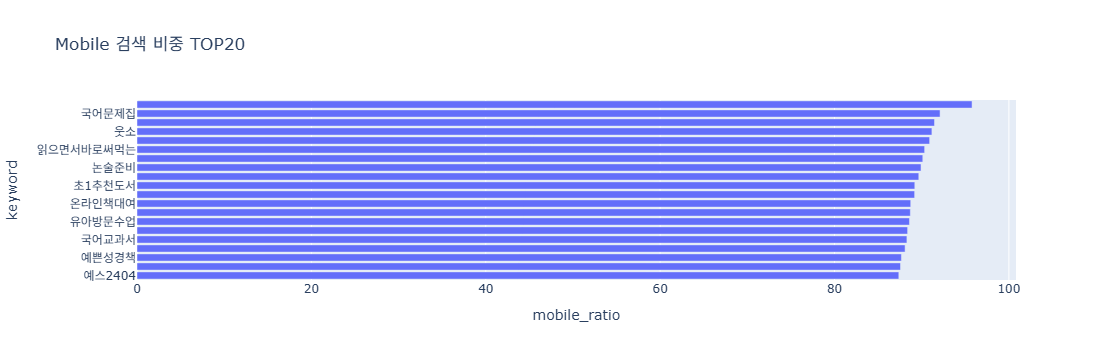

In [83]:
fig = px.bar(
    mobile_keywords,
    x="mobile_ratio",
    y="keyword",
    orientation="h",
    title = "Mobile 검색 비중 TOP20"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

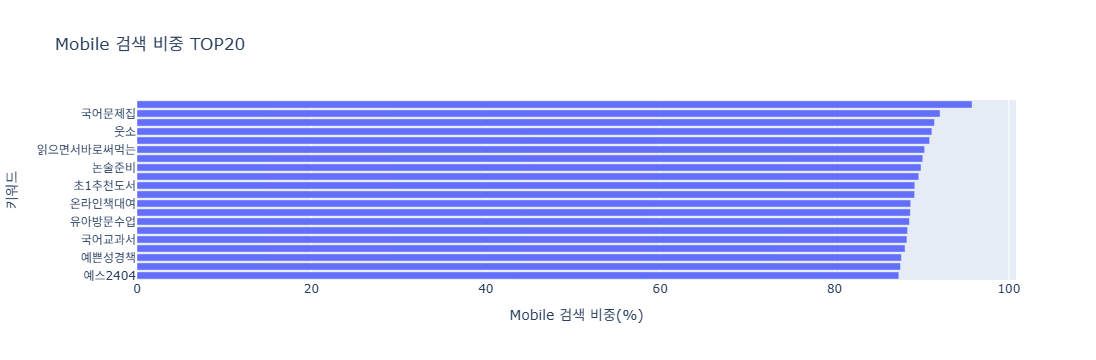

In [84]:
fig = px.bar(
    mobile_keywords,
    x="mobile_ratio",
    y="keyword",
    orientation="h",
    title="Mobile 검색 비중 TOP20",

    labels={
        "keyword": "키워드",
        "mobile_ratio": "Mobile 검색 비중(%)",
        "search_total": "전체 검색량"
    }
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

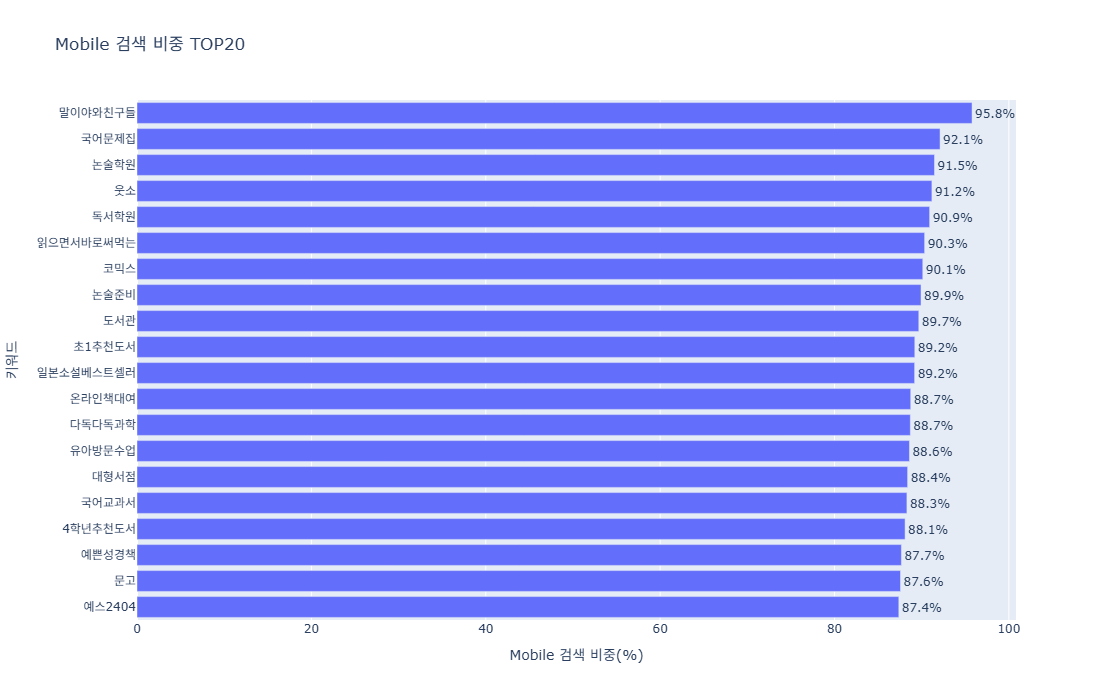

In [85]:
fig = px.bar(
    mobile_keywords,
    x="mobile_ratio",
    y="keyword",
    orientation="h",
    title="Mobile 검색 비중 TOP20",

    labels={
        "keyword": "키워드",
        "mobile_ratio": "Mobile 검색 비중(%)",
        "search_total": "전체 검색량"
    },

    hover_data=[
        "search_total",
        "search_mobile"
    ],

    text="mobile_ratio"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=700
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)
fig.show()

In [86]:
# 네번째 : 단순 검색량만 높은게 아니라, 클릭빈도 = 클릭율이 높은 키워드 & 모바일 검색수가 500이상

df[df["search_mobile"] >= 500]

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799
...,...,...,...,...,...,...,...,...,...,...,...,...
986,E북무료,210.0,1230.0,2.4,35.6,1.17,3.06,높음,9,1440.0,38.0,85.416667
989,무료전자책,650.0,2490.0,10.8,52.0,1.70,2.20,높음,10,3140.0,62.8,79.299363
991,구미호식당,130.0,850.0,1.9,16.0,1.44,2.05,중간,6,980.0,17.9,86.734694
992,로맨스소설,420.0,2740.0,1.7,59.8,0.42,2.35,높음,10,3160.0,61.5,86.708861


In [87]:
# 네번째 : 단순 검색량만 높은게 아니라, 클릭빈도 = 클릭율이 높은 키워드 & 모바일 검색수가 500이상
# 모바일 검색수가 500이상 검색되는 자료 바탕으로 20개
top_ctr_mobile = (
    df[df["search_mobile"] >= 500]
    .sort_values(
        "ctr_mobile",
        ascending=False # 내림 차순
    )
    .head(20)
    .copy()

)

In [88]:
top_ctr_mobile

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
568,무협소설,1000.0,5100.0,49.7,623.4,5.25,12.97,높음,10,6100.0,673.1,83.606557
499,코믹스,240.0,2190.0,6.3,238.4,2.73,11.69,중간,6,2430.0,244.7,90.123457
174,예스24이사,120.0,560.0,5.4,55.8,4.55,10.35,높음,10,680.0,61.2,82.352941
946,온라인책대여,170.0,1340.0,7.7,127.7,4.54,10.15,중간,8,1510.0,135.4,88.741722
178,책구매사이트,240.0,890.0,14.9,81.0,6.06,9.58,높음,10,1130.0,95.9,78.761062
234,서점당일배송,50.0,680.0,2.3,58.9,4.43,9.18,높음,9,730.0,61.2,93.150685
71,2424,240.0,980.0,6.2,79.6,2.67,8.58,높음,10,1220.0,85.8,80.327869
118,책구매,310.0,780.0,16.7,63.4,5.50,8.39,높음,10,1090.0,80.1,71.559633
285,성경책구입,90.0,550.0,4.7,41.8,5.42,8.00,높음,7,640.0,46.5,85.937500
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799


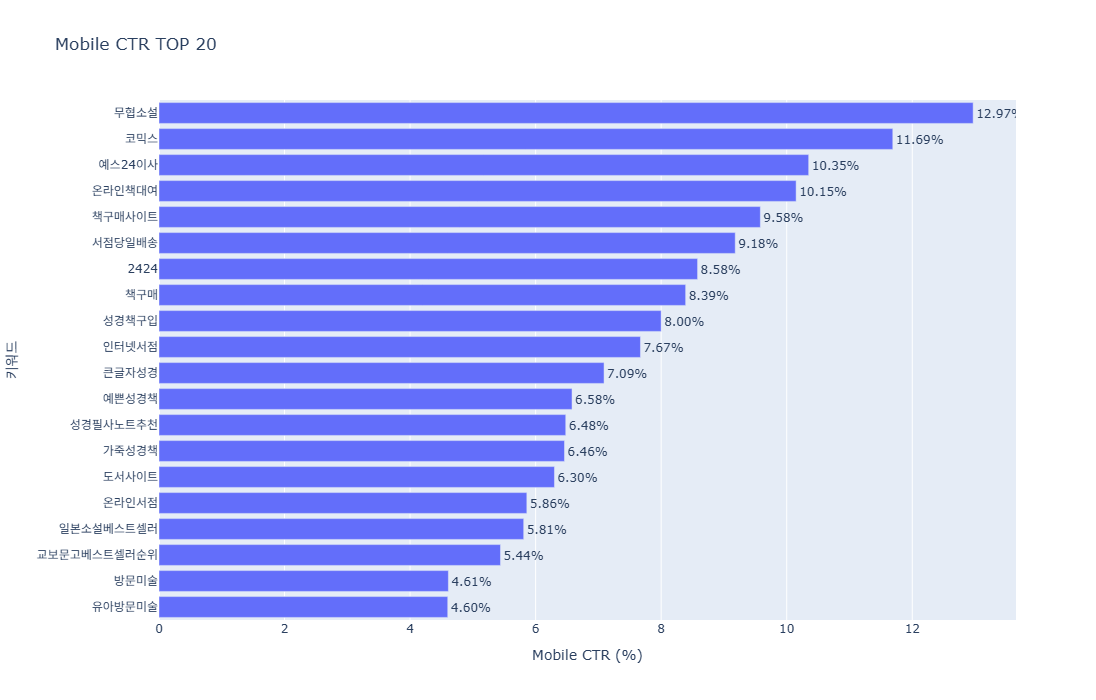

In [93]:
fig = px.bar(
    top_ctr_mobile,
    x="ctr_mobile",
    y="keyword",
    orientation="h",

    title="Mobile CTR TOP 20",

    labels={
        "keyword": "키워드",
        "ctr_mobile": "Mobile CTR (%)",
        "search_mobile": "Mobile 검색량"
    },

    hover_data = [
        "search_mobile",
        "click_mobile",
        "competition"
    ],

    text="ctr_mobile"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis={
        "categoryorder": "total ascending"
    },
    height=700 
)

fig.show()

In [ ]:
fig = px.bar(
    top_ctr_mobile,
    x="ctr_mobile",
    y="keyword",
    orientation="h",

    title="Mobile CTR TOP 20",

    labels={
        "keyword": "키워드",
        "ctr_mobile": "Mobile CTR (%)",
        "search_mobile": "Mobile 검색량"
    },

    hover_data = [
        "search_mobile",
        "click_mobile",
        "competition"
    ],

    text="ctr_mobile"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis={
        "categoryorder": "total ascending"
    },
    height=700 
)

fig.show()

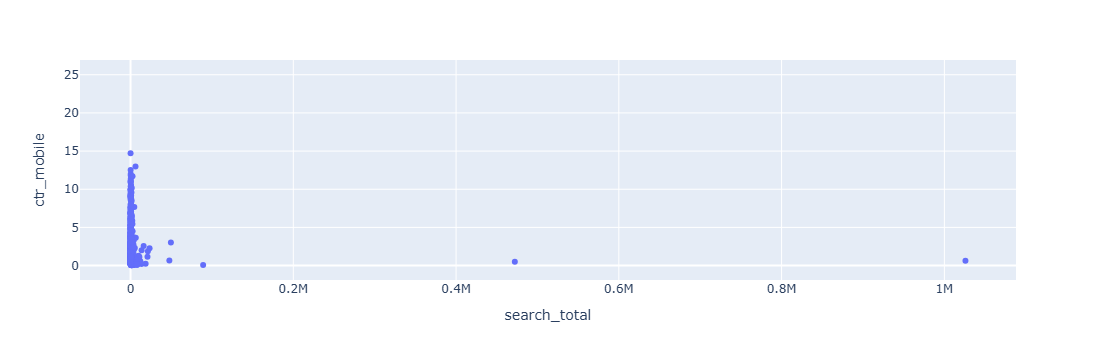

In [94]:
# 산점도 차트(점을 흩뿌려서 만든 차트) : 밀(집)도 => 어느 한 구간에 많이 몰려있다. 
# 산점도 차트는 데이터 패턴을 알 수 있다. 어느 구간, 어떤 타켓, 가격, 시간, 장소 등을 선호
# 차트 목적에 맞춰서 사용!! 
# 범주형 데이터 : 남.여 / 10대.20대.30대 / 내국인.외국인 
# 절대빈도 값 조회.분석 : 절대값 => 막대그래프 
# 상대빈도 값 조회.분석 : 상대값 => 원형 = 파이차트 // 도넛차트 
# 시계열 데이터 : 시간 경과에 따라서 값의 변화가 존재할 수 있는 데이터 : 주식차트, 부동산 전월세 임대비
# 꺾은선 차트 

fig = px.scatter(
    df,
    x="search_total",
    y="ctr_mobile",

    title = "검색량과 Mobile CTR의 관계"
)

fig.show() # 상관관계가 없다는 것으로 추청할 수 있다.

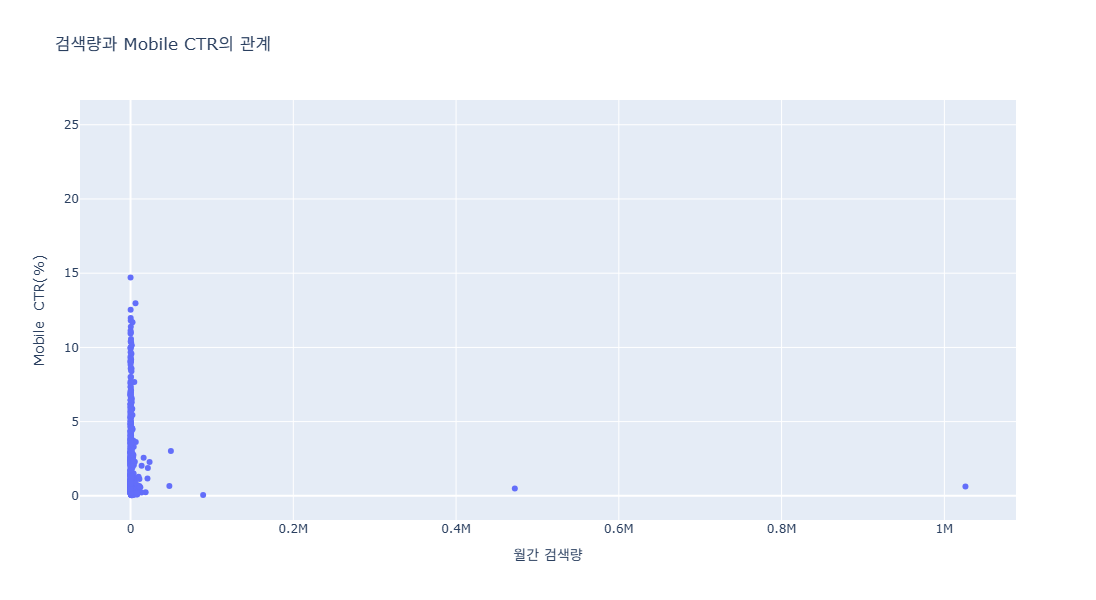

In [96]:
fig = px.scatter(
    df,
    x="search_total",
    y="ctr_mobile",

    title = "검색량과 Mobile CTR의 관계",

    labels={
        "search_total": "월간 검색량",
        "ctr_mobile": "Mobile  CTR(%)",
        "keyword":"키워드"
    },
    hover_name="keyword",

    hover_data=[
        "search_pc",
        "search_mobile",
        "competition"
    ]
)

fig.update_layout(
    height=600
)

fig.show() # 상관관계가 없다는 것으로 추청할 수 있다. 검색량이 높다고 해서 클릭율이 높다는건 아니다. 

In [97]:
df["search_total"].corr(df["ctr_mobile"])
# corr = correlation = 상관관계
# 상관계수 = -1(음의상관관계) ~ 0 ~ 1(양의상관관계) 

np.float64(-0.04458516703536998)

In [ ]:
# 로그 스케일 = log scale(사이즈, 범위) =  

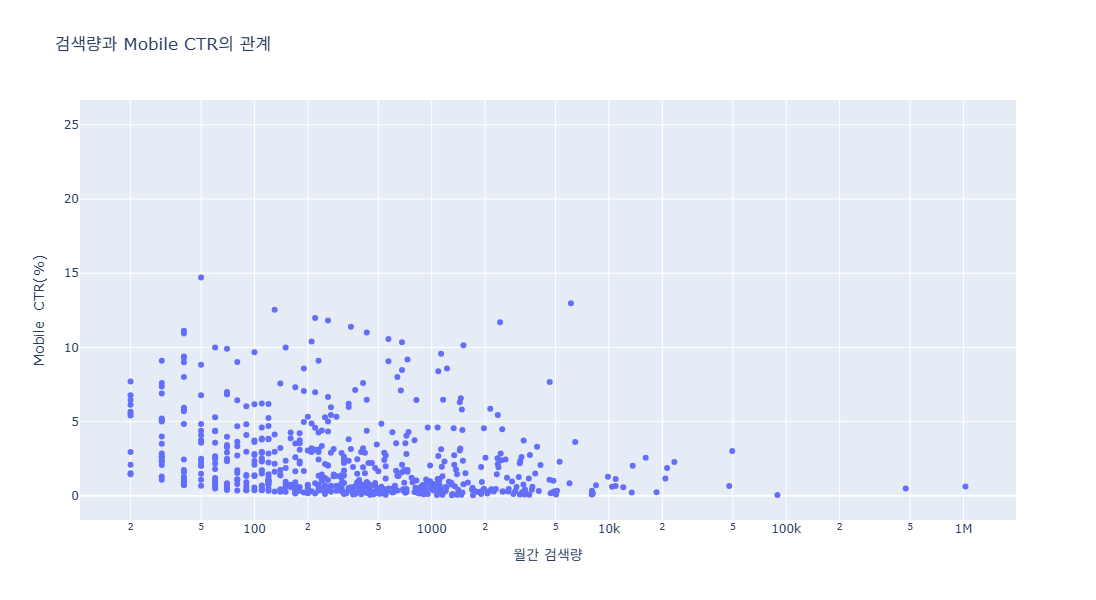

In [98]:
fig = px.scatter(
    df,
    x="search_total",
    y="ctr_mobile",
    log_x=True,

    title = "검색량과 Mobile CTR의 관계",

    labels={
        "search_total": "월간 검색량",
        "ctr_mobile": "Mobile  CTR(%)",
        "keyword":"키워드"
    },
    hover_name="keyword",

    hover_data=[
        "search_pc",
        "search_mobile",
        "competition"
    ]
)

fig.update_layout(
    height=600
)

fig.show() # 상관관계가 없다는 것으로 추청할 수 있다. 검색량이 높다고 해서 클릭율이 높다는건 아니다. 

특정 키워드의 경우, 월간 전체 검색량 대비 모바일 클릭율이 비례해서 증가하는 양의 상관관계를 가지고 있으나, 
전체적으로 월간 검색량과 모바일 클릭율은 관계가 밀접하게 있다고 보기 어렵다고 추정(가설) 

In [ ]:
# 전체검색량 > 모바일 검색량 > 모바일 클릭률 > 월간 전체 검색량 & 모바일 클릭률 관계 
# 경쟁정도 (얼마나 많은 경쟁업체들이 해당 키워드를 놓고 광고 키워드 선점을 위해 경쟁하고 있는가) 
# 현재 1000개의 키워드는 모두 각각 경쟁정도 값 가지고 있음 
# 전체 1000개의 키워드들이 각각 경쟁정도 비율이 어떻게 되는지

In [10]:
df["competition"]

0      높음
1      높음
2      낮음
3      높음
4      높음
       ..
995    중간
996    높음
997    높음
998    높음
999    높음
Name: competition, Length: 1000, dtype: str

In [11]:
df["competition"].value_counts()

competition
높음    833
중간    132
낮음     35
Name: count, dtype: int64

In [105]:
competition_count = df["competition"].value_counts().reset_index()
competition_count

,competition,count
0,높음,833
1,중간,132
2,낮음,35


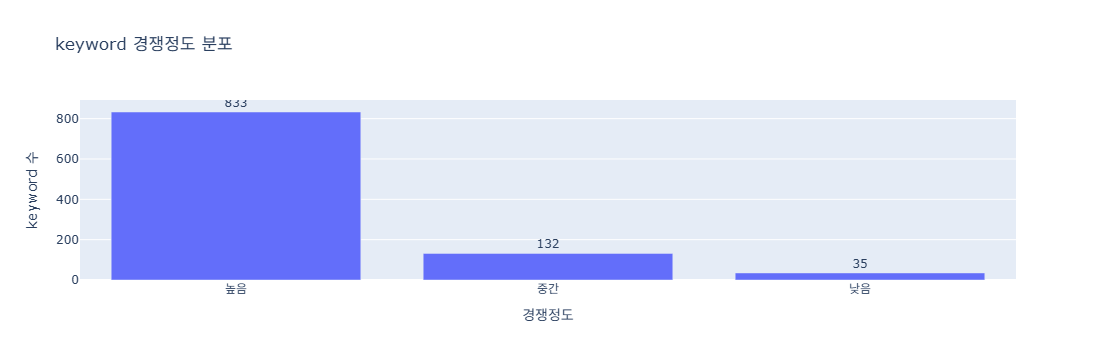

In [106]:
fig = px.bar(
    competition_count,
    x="competition",
    y="count",

    title="keyword 경쟁정도 분포",

    labels={
        "competition": "경쟁정도",
        "count": "keyword 수"

    },

    text="count"
)

fig.update_traces(textposition="outside")

fig.show()

In [14]:
competition_ratio = (
    df["competition"]
    .value_counts(normalize=True)
    .mul(100)
)

competition_ratio = ["competition", "ratio"]

In [15]:
competition_ratio

competition
높음    83.3
중간    13.2
낮음     3.5
Name: proportion, dtype: float64

In [16]:
competition_summary = df.groupby("competition").agg(
    keyword_count=("keyword", "count"), 
    avg_search=("search_total", "mean"),
    median_search=("search_total", "median"),
    avg_ctr_mobile=("ctr_mobile", "mean")
).reset_index().round(2) 

KeyError: "Label(s) ['search_total'] do not exist"

In [17]:
competition_summary

NameError: name 'competition_summary' is not defined

In [25]:
fig = px.bar(
    competition_summary,
    x="competition",
    y="avg_search",

    title="경쟁도별 평균 검색량",

    lables={
        "competition": "경쟁정도",
        "avg_search": "평균 검색량"
    },

    text="avg_search"
)

fig.update_traces(
    texttemplate="{text:,.0f}",
    textposition="outside"
)

fig.update_traces(textposition="outside")

fig.show()

NameError: name 'px' is not defined

In [21]:
 # 낮음, 높음, 중간 => 문자열 => 정량 데이터 x
competition_map = {
    "낮음":1,
    "중간":2,
    "높음":3
}

df["competition_score"] = df["competition"].map(competition_map)

In [22]:
df

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,competition_score
0,도서,"7,780","13,500",84.0,239.2,1.11,1.88,높음,10,3
1,독서,"1,070","3,840",0.5,10.4,0.05,0.29,높음,10,3
2,YES24,"168,900","303,300",111.0,"1,412",0.08,0.50,낮음,1,1
3,베스트셀러,"13,000","36,600",118.6,"1,031.9",0.93,3.02,높음,10,3
4,인터넷서점,"1,620","3,010",78.3,218.8,4.99,7.67,높음,10,3
...,...,...,...,...,...,...,...,...,...,...
995,난책읽기가좋아2단계,20,120,0.1,2,0.68,1.74,중간,7,2
996,너도하늘말나리야,160,680,0.0,0,NaN,NaN,높음,3,3
997,국어문제,60,250,0.4,2,0.69,0.84,높음,10,3
998,무료한글공부,30,10,0.3,0,0.80,NaN,높음,7,3


In [ ]:
# 전체 검색량 > 모바일 검색량 > 모바일클릭율 > 경쟁정도 

In [26]:
fig = px.scatter(
    df,
    x="search_total",
    y="competition_score",

    title="Search Volumn x Competition",

    labels={
        "search_total":"월간 검색량",
        "competition_score": "경쟁정도"
    },

    hover_name="keyword",

    hover_data = [
        "competition",
        "ctr_mobile",
        "ad_count"
    ]
)

fig.update_yaxes(
    tickvals=[1,2,3],
    ticktext=["낮음", "중간", "높음"]
)



fig.show()

NameError: name 'px' is not defined

In [27]:
df["search_total"]

KeyError: 'search_total'